## Lab 3: Differential Diagnosis and Conditional Expectation

**Names: Claire Jones, Samuel Harris, Henry Jones, Ryan Jamison, Eric Hoerdemann**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [2]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


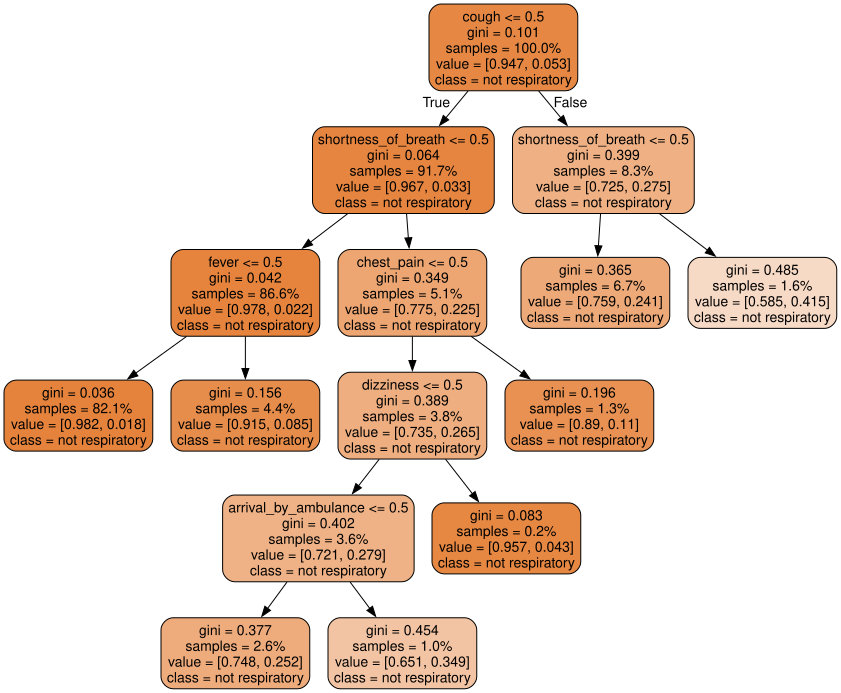

In [3]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4,# Minimum impurity decrease to split a node #CHANGE THIS LINE
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

Which variables does the tree exploit? 

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

</div>

If you do have a cough and do have shortness of breath, then you are most likely to have respiratory disease. There is a 41.5% chance.

If you do not have a cough, do not have shortness of breath, and do not have a fever, then you are least likely to have respiratory disease. There is only a 1.8% chance.

The tree exploits the following variables: cough, shortness_of_breath, fever, chest_pain, dizziness, and arival_by_ambulance

This tree represents conditional updating since it recalculates the probability of having a respiratory disease after each new variable is "tested". As you move down the branch, based on the previous variable, you get an "updated" probability that takes into account all of the reported symptoms so far.

At 1e-3=0.001, you are at the highest probability of resiratory disease if you have a cough, at 27.5%. You are at the lowest probability to have resiratory disease if you do not have a cough and you do not have shortness of breath

At 1e-5=0.00001, you are at the highest probability of resiratory disease if you have a cough, have shortness of breath, do not have chest pain, do not have a headache, you are over 70 years old, sex = 1, at 55.5% chance. You are at the lowest probability to have resiratory disease if you do not have a cough, you do not have shortness of breath, you do not have a fever, you do not have chest pain, but you did have an accident, this puts you at a 0% chance. Since it is unlikely that there is a 0% chance, the next lowest probabilty is is if you do not have a cough, you do not have shortness of breath, you do not have a fever, you do not have chest pain, you did not have an accident, and your age is between 20 and 40 year old, you are at a 1.2% chance.

At 1e-7=0.0000001, you are at the highest probability of resiratory disease if you have a cough, have shortness of breath, do not have chest pain, do not have a headache, you are over 70 years old, sex = 0, and you did not arrive by ambulance. This puts you at a probability of 57.7%. For the lowest probability of resiratory disease, there are several combinations of symptoms that get you to the lowest. In fact, 12 combinations lead to a probability of 0% chance of resiratory disease, with them all rooting from not hving a cough.

As a tree becomes more complex, there is an increase in "splits". As a tree becomes more comples, the tree is going to fomr more and more branches with smaller samples and precentages. This shows overfitting of the model. When a model is less complex, the tree is more balanced. All of the higher probabilities come from if you do have a cough, while the lower probabilities all come from not having a cough. The result just gets more and more specific as you increase compelxity.

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

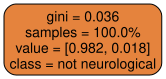

In [4]:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

model_2 = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3,# Minimum impurity decrease to split a node #CHANGE THIS LINE
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model_2.fit(X, y)

dot_data = export_graphviz(
    model_2, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The decision tree doesn't split into any branches with the min impurity set to 1e-3. The root node contains all of the observations, with 98.2% classified as not neurological and 1.8% as neurological. Therefore, the model predicts a neurological diagnosis 1.8% of the time for all observations but it classifies every observation as not neurological. There aren't any variables to raise or lower the predicted probability of a neurological diagnosis, since there aren't any splits in the tree.

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

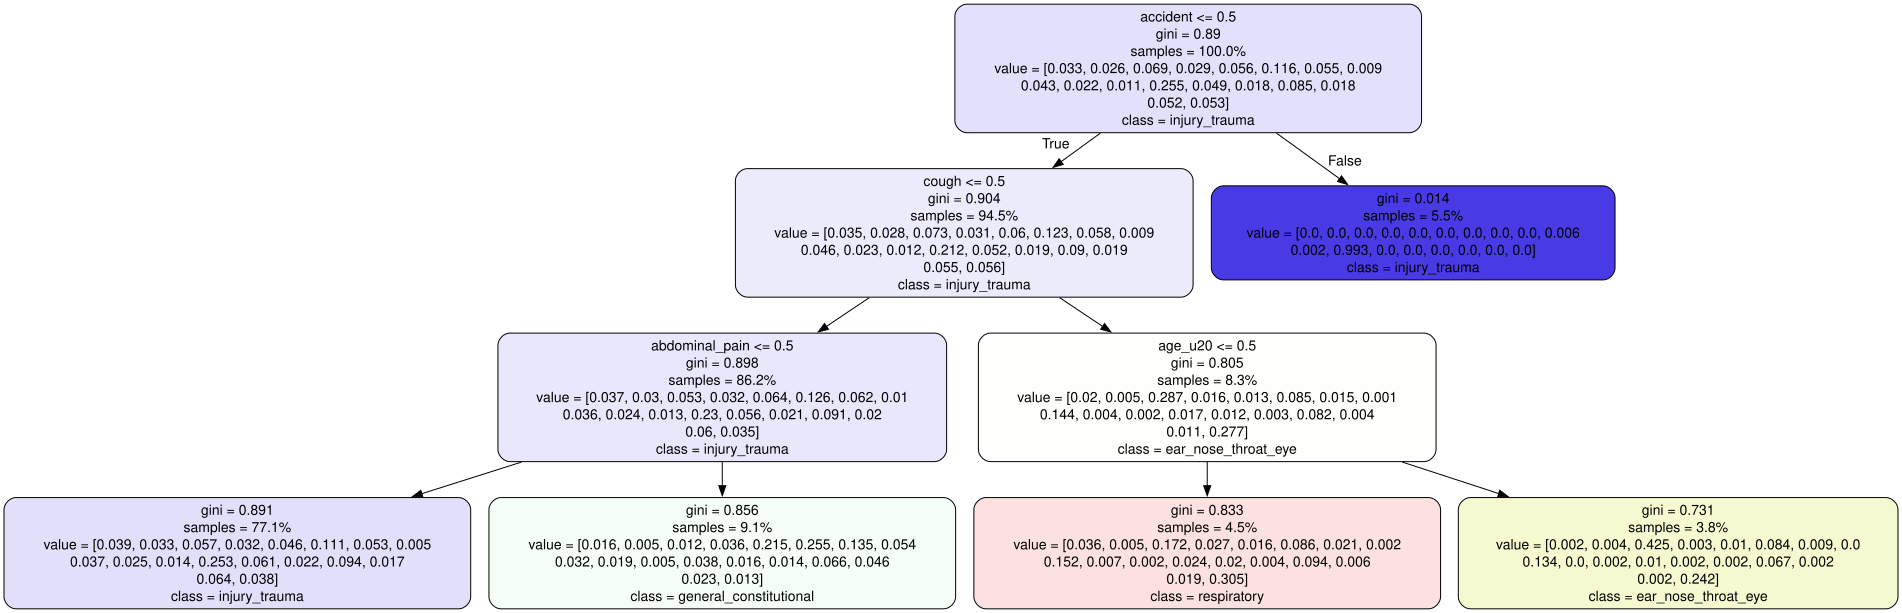

In [4]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Which conditions and values are used in the tree?

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

</div>

Injury trauma, general constitutional, respiratory, and ear/nose/troat/eye are the four predicted diseases. Once we get past the first question asking if there was an accident, the probabibilty of these diseases never pass .5 (accidents seem to basically always mean injury trauma, which isn't really a disease). The class of ear_nose_throat_eye exceeds .3 with the largest probability of .425 (42.5%) and respiratory excees .3 by a slim margin with a .305 probability. The other two classes do not exceed .3, but are both somewhat close at around 20-25%. This is concerning because no one issue is much more common than the others, and for each of the diagnoses with the highest probability, there is still a >50% chance that the most likely diagnosis will be wrong. This lack of certainty of what disease or issue a patient could have is an issue.

The dark blue box tells us that injury trauma has a probability of 99.3% when an accident occurs, which is basically everyone in the dataset for that subsample. General constitutional is the weakest predicted disease class with only a probability of 21.5%.

The conditions consisted of whether or not the patient had an accident, has a cough, has any abdominal pain, and whether they were over or under 20. The values to go aalong with these conditions are all 0.5, meaning yes or no questions. If they had over 0.5 cough, that meant they had a cough. 

Even if the probabilities are low, a tree can help doctors narrow down the ponential disease or thing wrong with the patient. By following the tree through the potential condidtions, a doctor can have a better idea of a potential diagnosis. It might not be difinitive each time, but at the very least a tree like this can rule out one or more potential diagnosis. It also helps focus  their attention on to the most likely diseases, which could save them time on running tests if they were to work through diagnoses from the most to least likely.